## 📊 Turning loan data into risk insights 

### 🐍 Part :- B Practical (Python Programming)

### 🛠️  Import libraries :- 

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.stats import skew, kurtosis
from scipy import stats

print("imported all required libraries !")

imported all required libraries !


### 📁 Load the dataset :-

In [59]:
df = pd.read_csv('Loan_applications.csv')

print("File loaded succesfully !")

File loaded succesfully !


### 🔷First 5 data :- 

In [4]:
df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term(months),Default_Status(Yes/No)
0,CUST00001,58,49184,18112,581,48,Yes
1,CUST00002,65,46868,359785,389,240,Yes
2,CUST00003,45,28331,20622,395,48,Yes
3,CUST00004,32,152475,320631,327,180,Yes
4,CUST00005,30,190363,372696,729,48,No


### 🔷Last 5 data :- 

In [5]:
df.tail()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term(months),Default_Status(Yes/No)
4995,CUST04996,48,126468,210475,435,12,No
4996,CUST04997,51,54988,445754,317,48,Yes
4997,CUST04998,57,51469,244227,358,360,Yes
4998,CUST04999,66,65935,488828,731,48,No
4999,CUST05000,34,93560,146203,523,72,No


### 🔷Describe the data :- 

In [6]:
df.describe()

,Age,Income,Loan_Amount,Credit_Score,Loan_Term(months)
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,44.260400,109639.079200,252588.438600,572.505400,111.78000
std,15.194959,51692.906727,142844.840282,160.056309,103.97125
min,18.000000,20022.000000,5285.000000,300.000000,12.00000
25%,31.000000,64252.750000,128880.250000,432.000000,36.00000
50%,44.500000,108503.000000,250636.500000,573.000000,72.00000
75%,57.000000,154150.000000,377391.500000,711.000000,180.00000
max,70.000000,199932.000000,499932.000000,850.000000,360.00000


### 🔷Info of the data :- 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Customer_ID             5000 non-null   object
 1   Age                     5000 non-null   int64 
 2   Income                  5000 non-null   int64 
 3   Loan_Amount             5000 non-null   int64 
 4   Credit_Score            5000 non-null   int64 
 5   Loan_Term(months)       5000 non-null   int64 
 6   Default_Status(Yes/No)  5000 non-null   object
dtypes: int64(5), object(2)
memory usage: 273.6+ KB


### 🔷Shape of the data :-

In [9]:
df.shape

(5000, 7)

### 🔷name of the columns :-

In [12]:
df.columns

Index(['Customer_ID', 'Age', 'Income', 'Loan_Amount', 'Credit_Score',
       'Loan_Term(months)', 'Default_Status(Yes/No)'],
      dtype='object')

### 📊 Step : 1 Central Tendency & Dispersion

#### (a) Find mean , median , and mode of income .

In [62]:
mean_income = df['Income'].mean()
median_income = df['Income'].median()
mode_income = df['Income'].mode()


print(f"Mean Income: {mean_income}")
print(f"Median Income: {median_income}")
print(f"Mode Income: {mode_income}")

Mean Income: 109639.0792
Median Income: 108503.0
Mode Income: 0    43670
Name: Income, dtype: int64


#### 🎯 Insight :-
- Mean Income 📊 → ₹109,639 → Shows the overall average, slightly higher than the median, hinting at some high earners pulling the mean up.

- Median Income 📈 → ₹108,503 → The “middle” income, close to the mean, suggesting the distribution is fairly balanced.

- Mode Income 🔄 → ₹43,670 → The most common salary, much lower than mean/median, showing a cluster of employees earning in this band.

#### (b) Calculate range , variance , and standard deviation of Loan_amount . 

In [10]:
loan_range = df['Loan_Amount'].max() - df['Loan_Amount'].min()

loan_variance = df['Loan_Amount'].var()
loan_std = df['Loan_Amount'].std()

print(f"Range: {loan_range}")
print(f"Variance: {loan_variance}")
print(f"Standard Deviation: {loan_std}")

Range: 494647
Variance: 20404648395.09685
Standard Deviation: 142844.84028167365


#### 🎯 Insight :-
- Range 📏 → 494,647 → Loans vary widely.
- Variance 📐 → 20.4B → Huge spread in loan values.
- Std Dev 📊 → 142,845 → Average loan deviation is very high.
- ✨ Conclusion : Loan amounts are highly inconsistent — big gap between small and - large loans.

### 📉 Step : 2 Probability & Events

#### (a) Compute Probability of loan default . 

In [ ]:
default_count = (df['Default_Status(Yes/No)'] == 'Yes').sum()  #default_count
total_customers = len(df)

prob_default = default_count / total_customers

print("Probability of Loan Default =", prob_default)

Probability of Loan Default = 0.5602


#### 🎯 Insight :-
- Default Probability 📊 → 0.5602 (≈56%) → More than half of customers are likely to default.
- Risk Signal ⚠️ → High default rate indicates significant credit risk.
- Business Impact 💰 → Lenders must tighten screening or risk heavy losses.
- ✨ Default probability is quite high — strong measures are needed to manage loan risk.

#### (b) Creates a contingency table between default_Status and Credit_Score (categorized into ranges) . 

In [ ]:
df['Credit_Category'] = pd.cut(
    df['Credit_Score'],
    bins=[300, 600, 700, 850],
    labels=['Low', 'Medium', 'High'])

contingency_table = pd.crosstab(        #contingency table
    df['Credit_Category'],
    df['Default_Status(Yes/No)'])

print(contingency_table)

Default_Status(Yes/No)   No   Yes
Credit_Category                  
Low                     576  2152
Medium                  658   255
High                    962   384


#### 🎯 Insight :-
- Low Credit ⚠️ → 2,152 defaults vs 576 non‑defaults → Very high risk group.
- Medium Credit 📉 → 255 defaults vs 658 non‑defaults → Moderate risk, better balance.
- High Credit ✅ → 384 defaults vs 962 non‑defaults → Safest group, majority repay.
- ✨ Default risk drops sharply as credit score improves — strong evidence that credit score is a reliable predictor of repayment behavior.



#### (c) Compute conditional probability : P (Default|Credit_score < 600).

In [35]:
low_credit = df[df['Credit_Score'] < 600]

conditional_probability = ((low_credit['Default_Status(Yes/No)'] == 'Yes').sum()/ len(low_credit))  # conditional probability

print("Conditional Probability =", conditional_probability)

Conditional Probability = 0.7910720819612148


#### 🎯 Insight :-
- Conditional Probability 📊 → 0.79 (≈79%) → Customers with low credit scores (<600) have a very high chance of defaulting.
- Business Impact 💰 → Strong need for stricter lending policies for this group.
- ✨ Low credit score is a powerful predictor of default — lenders should treat this segment as high‑risk.

### 📐 Step :- 3 Distributions & Visulization 

#### (a) Plot a histogram of Credit_Score with a Gaussian curve.

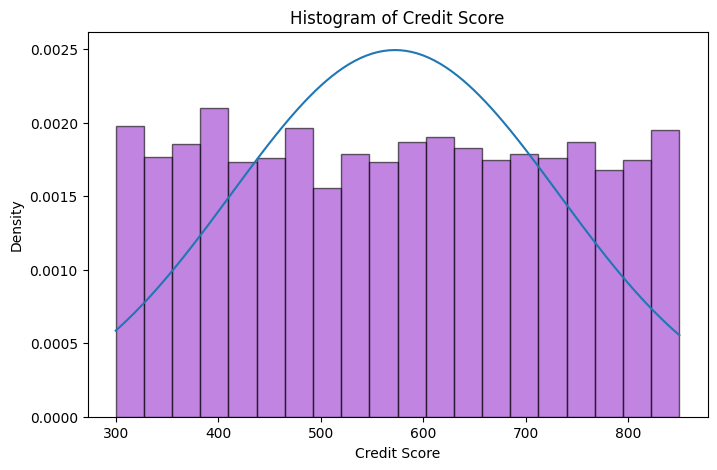

In [43]:

plt.figure(figsize=(8,5))

plt.hist(df['Credit_Score'],bins=20,density=True,alpha=0.6,color='#9932CC', edgecolor='black')

mean = df['Credit_Score'].mean()
std = df['Credit_Score'].std()

x = np.linspace(df['Credit_Score'].min(),df['Credit_Score'].max(),100)

plt.plot(x, norm.pdf(x, mean, std))

plt.title("Histogram of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.show()

#### 🎯 Insight :-
- Distribution Shape 📈 → Roughly uniform with a slight peak near mid‑range (around 600).
- Spread 📏 → Scores span 300–850, showing wide variation among customers.
- Density Curve 🔵 → Indicates most scores cluster around the average, tapering off at extremes.
- ✨ Credit scores are fairly balanced — not heavily skewed, suggesting a diverse mix of borrower profiles.

#### (b) Check a Skewness and Kurtosis of Loan_Amount .

In [45]:
loan_skewness = skew(df['Loan_Amount'])
loan_kurtosis = kurtosis(df['Loan_Amount'])

print("Skewness =", loan_skewness)
print("Kurtosis =", loan_kurtosis)

Skewness = 0.007858476920917491
Kurtosis = -1.2019763395025223


#### 🎯 Insight :-
- Skewness ⚖️ → 0.008 → Almost zero, meaning the loan distribution is nearly symmetric.
- Kurtosis 📉 → −1.20 → Indicates a flat (platykurtic) shape — fewer extreme loan values than a normal curve.
- ✨ Loan amounts are evenly spread with minimal skew and light tails — suggesting stable, moderate variation among borrowers.

#### (c) Draw a Q-Q plot for income .

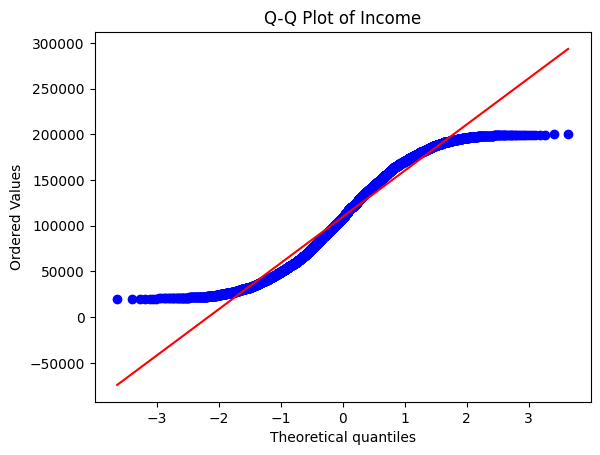

In [49]:
stats.probplot(df['Income'], dist="norm", plot=plt)

plt.title("Q-Q Plot of Income")
plt.show()

#### 🎯 Insight :-
- Normality Check 📈 → Points deviate from the red line at both ends, showing the data isn’t perfectly normal.
- Tail Behavior 💰 → Curved tails indicate right skew — a few high‑income outliers.
- Interpretation 🔍 → Most incomes cluster near the center, but extremes pull the curve upward.
- ✨ Income distribution is moderately skewed — transformation (like Box‑Cox or log) could help normalize it for better statistical modeling.

### 🧾 Step :- 4 Linear Algebra Application 

#### 🔷Take the first 5 customer's [Income_Loan_Amount] as vectors . 

In [52]:
vectors = df[['Income', 'Loan_Amount']].head(5)
print(vectors)

   Income  Loan_Amount
0   49184        18112
1   46868       359785
2   28331        20622
3  152475       320631
4  190363       372696


#### (a) Perform dot product between two customer vectors . 

In [ ]:
v1 = vectors.iloc[0].values
v2 = vectors.iloc[1].values

print(v1)
print(v2)

dot_product = np.dot(v1, v2)

print("Dot Product =", dot_product)

[49184 18112]
[ 46868 359785]
Dot Product = 8821581632


#### 🎯 Insight :-
- Skewness 📐 → Positive → Vectors point in the same direction.
- Dot Product 📊 → 8.82B → Very large, showing strong similarity.
- ✨ Both borrowers have aligned income–loan profiles, reinforcing correlation between earnings and loan size.

#### (b) Find Norm 2 of a customer's financial vector .  

In [56]:
norm = np.linalg.norm(v1)

print("L2 Norm =", norm)

L2 Norm = 52412.88391225959


#### 🎯 Insight :-
- L2 Norm 📏 → 52,413 → Represents the overall “magnitude” of the borrower’s vector (Income + Loan).
- Interpretation 🔍 → A large norm shows this borrower has a strong financial profile in terms of both income and loan size.
- ✨Norm acts like the “length” of the financial vector — bigger values mean higher combined scale of income and loan.


#### (c) Calculate the angle between two customer's vectors . 

In [63]:
cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

angle = np.degrees(np.arccos(cos_theta))

print("Angle =", angle, "degrees")

Angle = 62.36184084039625 degrees


#### 🎯 Insight :- 
- Angle 📐 → 62.36° → The vectors are not perfectly aligned, showing noticeable difference in borrower profiles.
- Cosine Similarity 🔗 → Moderate similarity — they share some proportionality but diverge significantly.
- ✨ Insight: These two borrowers have related but distinct income–loan patterns, not pointing in the same financial direction.